In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

In [2]:
df = pd.read_csv('../data/cleaned/cleaned_data.csv')

# Count null values in specific column
#print("Null values in Price column:", df['Price'].isnull().sum())
#print("Null values in Price column (alternative):", df['Price'].isna().sum())

# Count null values in all columns
#print("\nNull values in all columns:")
#print(df.isnull().sum())

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Type', 'Method'], prefix=['Type', 'Method'])

# Check what columns we have after encoding
#print("Columns after encoding:")
#print([col for col in df_encoded.columns if col.startswith(('Type_', 'Method_'))])

# prepare the data
df_train = df_encoded.dropna(subset=['Price'])
df_missing = df_encoded[df_encoded['Price'].isna()]

# Get all encoded feature columns (excluding non-feature columns)
#exclude_cols = ['Price', 'Date', 'Address', 'Suburb', 'SellerG', 'CouncilArea', 'Regionname', 'Bedroom2', 'Longtitude', 'Lattitude', 'Propertycount', 'missing_Price']
#features = [col for col in df_encoded.columns if col not in exclude_cols]

#print(f"Selected features: {features}")

features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Postcode', 'SaleYear','SaleMonth','HouseAge','LandsizePerRoom','PricePerSqm','RoomsPerBathroom','BuildingDensity'] #

X = df_train[features]
y = df_train['Price']

In [3]:
# train the model
best_params = {'bootstrap': False, 'max_depth': 14, 'max_features': 0.6,
               'min_samples_leaf': 5, 'min_samples_split': 12, 'n_estimators': 84}

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# predict on the missing values
X_missing = df_missing[features]
predicted_prices = model.predict(X_missing)

# add the predicted prices to the original dataframe
df.loc[df['Price'].isnull(), 'Price'] = predicted_prices

print(f'Predicted {len(predicted_prices)} missing prices.')

df['Price'] = df['Price'].round(0).astype(int)

# evaluate the model
predicted_prices_train = model.predict(X)
mae = mean_absolute_error(y, predicted_prices_train)
#accuracy = 1 - (mae / y.mean())
rmse = np.sqrt(mean_squared_error(y, predicted_prices_train))
r2 = r2_score(y, predicted_prices_train)
residuals = y - predicted_prices_train
print(f"R-squared (R2): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f'Mean Absolute Error on training set: {mae:.2f}')
#print(f'Accuracy on training set: {accuracy:.2%}')

Predicted 7566 missing prices.
R-squared (R2): 0.9987
Root Mean Squared Error (RMSE): 23266.00
Mean Absolute Error on training set: 3935.65


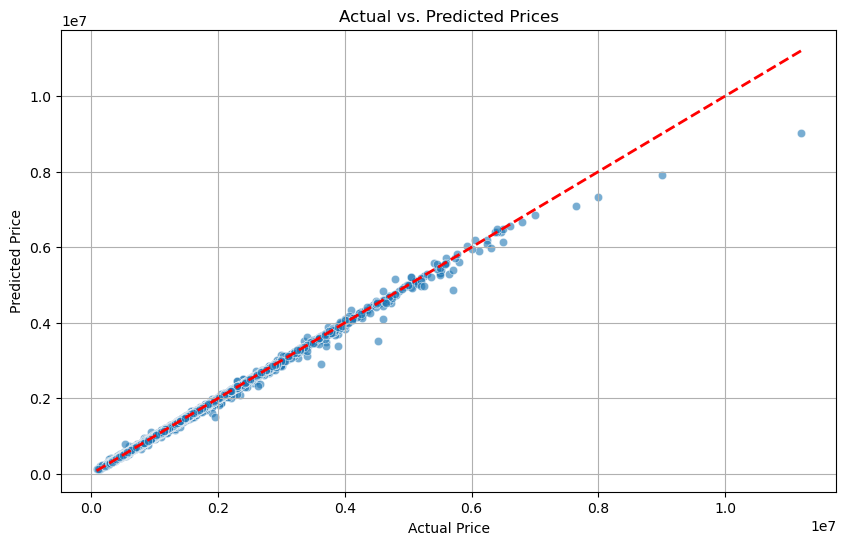

In [4]:
# Plot Predicted vs. Actual
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=predicted_prices_train, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Ideal 45-degree line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted Prices")
plt.grid(True)
plt.show()

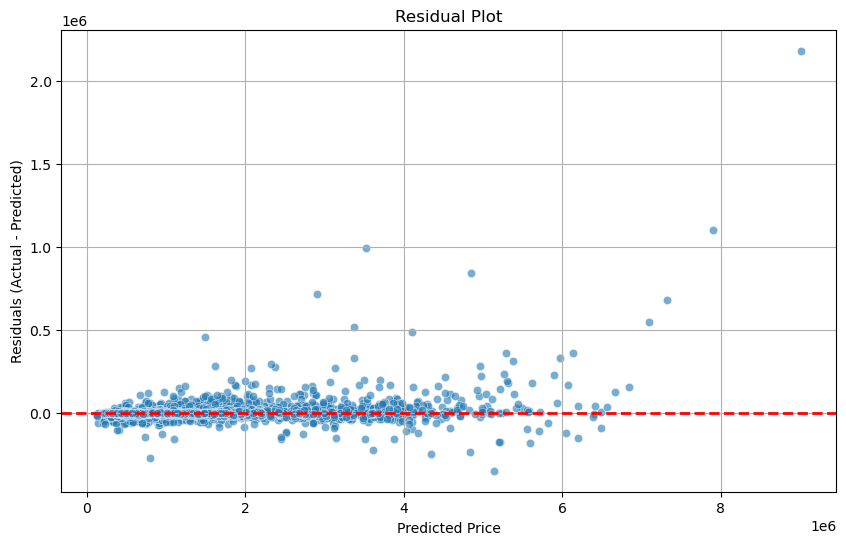

In [5]:
# Plot Residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicted_prices_train, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Line at zero error
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [6]:
# save updated dataframe
df.to_csv('../data/cleaned/cleaned_data_with_predictions.csv', index=False)

In [7]:
target_folder = '../models'

os.makedirs(target_folder, exist_ok=True)
#print(f"Ensured directory '{target_folder}' exists.")

# save the model
melb_house_model = os.path.join(target_folder, 'melb_house_model.pkl')

try:
    joblib.dump(model, melb_house_model)
    print(f"Model saved to {melb_house_model}")
except Exception as e:
    print(f"Error loading model: {e}")

# Verify the model load
""" print("\n--- Verifying model load ---")
try:
    loaded_model = joblib.load(joblib_filename)
    print(f"Model successfully loaded from '{joblib_filename}'")
    print(f"Type of loaded model: {type(loaded_model)}")

    # You can quickly check if parameters match
    # For example, check if the n_estimators match what you tuned
    # print(f"n_estimators of loaded model: {loaded_model.n_estimators}")
    # print(f"Expected n_estimators (from best_params_): {best_model.n_estimators}")

except FileNotFoundError:
    print(f"Error: Model file '{joblib_filename}' not found.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}") """




Model saved to ../models\melb_house_model.pkl


' print("\n--- Verifying model load ---")\ntry:\n    loaded_model = joblib.load(joblib_filename)\n    print(f"Model successfully loaded from \'{joblib_filename}\'")\n    print(f"Type of loaded model: {type(loaded_model)}")\n\n    # You can quickly check if parameters match\n    # For example, check if the n_estimators match what you tuned\n    # print(f"n_estimators of loaded model: {loaded_model.n_estimators}")\n    # print(f"Expected n_estimators (from best_params_): {best_model.n_estimators}")\n\nexcept FileNotFoundError:\n    print(f"Error: Model file \'{joblib_filename}\' not found.")\nexcept Exception as e:\n    print(f"An error occurred while loading the model: {e}") '

In [8]:

print("\n--- Cross-Validation using cross_val_score ---")
r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"R-squared scores for each fold: {r2_scores}")
print(f"Mean R-squared from CV: {r2_scores.mean():.4f}")
print(f"Standard Deviation of R-squared from CV: {r2_scores.std():.4f}")

# You can also get other metrics by changing 'scoring'
# For MAE, you need 'neg_mean_absolute_error' because scikit-learn's scoring functions
# are designed to be maximized (so errors are typically negative).
mae_scores = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"MAE scores for each fold: {[f'{score:.2f}' for score in mae_scores]}")
print(f"Mean MAE from CV: {mae_scores.mean():.2f}")
print(f"Standard Deviation of MAE from CV: {mae_scores.std():.2f}")

# For RMSE, you need 'neg_mean_squared_error'
rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error'))
print(f"RMSE scores for each fold: {[f'{score:.2f}' for score in rmse_scores]}")
print(f"Mean RMSE from CV: {rmse_scores.mean():.2f}")
print(f"Standard Deviation of RMSE from CV: {rmse_scores.std():.2f}")


# --- Option 2: Using cross_validate (for multiple metrics at once, and more detail) ---
print("\n--- Cross-Validation using cross_validate (more detailed) ---")
scoring = {
    'r2': 'r2',
    'mae': make_scorer(mean_absolute_error, greater_is_better=False), # greater_is_better=False for errors
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
}

cv_results = cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=False) # return_train_score=True if you want training scores too

print(f"R2 scores for each fold: {cv_results['test_r2']}")
print(f"MAE scores for each fold: {[f'{score:.2f}' for score in -cv_results['test_mae']]}")
print(f"RMSE scores for each fold: {[f'{score:.2f}' for score in -cv_results['test_rmse']]}")

print(f"\nMean CV R2: {cv_results['test_r2'].mean():.4f}")
print(f"Mean CV MAE: {-cv_results['test_mae'].mean():.2f}")
print(f"Mean CV RMSE: {-cv_results['test_rmse'].mean():.2f}")

# Compare to your original training set scores
print("\n--- Comparison ---")
print(f"Original Training R2: 0.9987")
print(f"Original Training MAE: 3935.65")
print(f"Original Training RMSE: 23266.00")



--- Cross-Validation using cross_val_score ---
R-squared scores for each fold: [0.99366619 0.98437764 0.98944519 0.98350839 0.99489397]
Mean R-squared from CV: 0.9892
Standard Deviation of R-squared from CV: 0.0046
MAE scores for each fold: ['15391.17', '18029.47', '13771.94', '7912.87', '7971.63']
Mean MAE from CV: 12615.42
Standard Deviation of MAE from CV: 4050.51
RMSE scores for each fold: ['56467.60', '74219.38', '63663.59', '83513.33', '43877.32']
Mean RMSE from CV: 64348.24
Standard Deviation of RMSE from CV: 13757.70

--- Cross-Validation using cross_validate (more detailed) ---
R2 scores for each fold: [0.99366619 0.98437764 0.98944519 0.98350839 0.99489397]
MAE scores for each fold: ['15391.17', '18029.47', '13771.94', '7912.87', '7971.63']
RMSE scores for each fold: ['56467.60', '74219.38', '63663.59', '83513.33', '43877.32']

Mean CV R2: 0.9892
Mean CV MAE: 12615.42
Mean CV RMSE: 64348.24

--- Comparison ---
Original Training R2: 0.9987
Original Training MAE: 3935.65
Origi